In [39]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

import optuna
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

import shap

In [ ]:
# Import the dataset using ucimlrepo API
fetched = fetch_ucirepo(id=891)

## Project understanding

This project aims to use the [CDC Diabetes Health Indicators](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators) dataset from UCI ML Repository to build a classifier model predicting whether a patient is likely to have pre-diabetes or diabetes.

The dataset is published on [Kaggle](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset) as well, with the original data coming from [CDC - 2014 Survey Data](https://www.cdc.gov/brfss/annual_data/annual_2014.html).

The project's objective is to develop a classifier with high sensitivity to diabetes patients, minimizing the risk of overlooking potential cases. This assumes that both medical facilities and patients are willing to undergo additional tests to mitigate the risk.

## Data Understanding

In [3]:
# The dataset is fetched and stored in the variable 'fetched'
df = fetched.data.original
df = df.set_index('ID')
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
ID,,,,,,,,,,,,,,,,,,,,,
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [4]:
# Check the types of the columns
df.dtypes

Diabetes_binary         int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [5]:
# Check the summary statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


**Note:** The data has no missing values and no data quality issues overall.

In [6]:
# Transform coded categorical variables into categorical types for better exploration
num_cols = ['BMI', 'MentHlth', 'PhysHlth']
df = df.astype({col:'category' for col in df.columns if col not in num_cols})

cat_cols = [col for col in df.select_dtypes(include='category').columns if col != 'Diabetes_binary']

df.dtypes

Diabetes_binary         category
HighBP                  category
HighChol                category
CholCheck               category
BMI                        int64
Smoker                  category
Stroke                  category
HeartDiseaseorAttack    category
PhysActivity            category
Fruits                  category
Veggies                 category
HvyAlcoholConsump       category
AnyHealthcare           category
NoDocbcCost             category
GenHlth                 category
MentHlth                   int64
PhysHlth                   int64
DiffWalk                category
Sex                     category
Age                     category
Education               category
Income                  category
dtype: object

In [7]:
# Explre the categorical variables
df.describe(include='category').T

,count,unique,top,freq
Diabetes_binary,253680,2,0,218334
HighBP,253680,2,0,144851
HighChol,253680,2,0,146089
CholCheck,253680,2,1,244210
Smoker,253680,2,0,141257
Stroke,253680,2,0,243388
HeartDiseaseorAttack,253680,2,0,229787
PhysActivity,253680,2,1,191920
Fruits,253680,2,1,160898
Veggies,253680,2,1,205841


In [8]:
# Check the balance of the target variable
df['Diabetes_binary'].value_counts()/ df.shape[0] * 100

Diabetes_binary
0    86.066698
1    13.933302
Name: count, dtype: float64

**Note:** The dataset has a significant calss imbalance in favor of the non-diabetic cases. Will need to be trated in the data preparation phase.

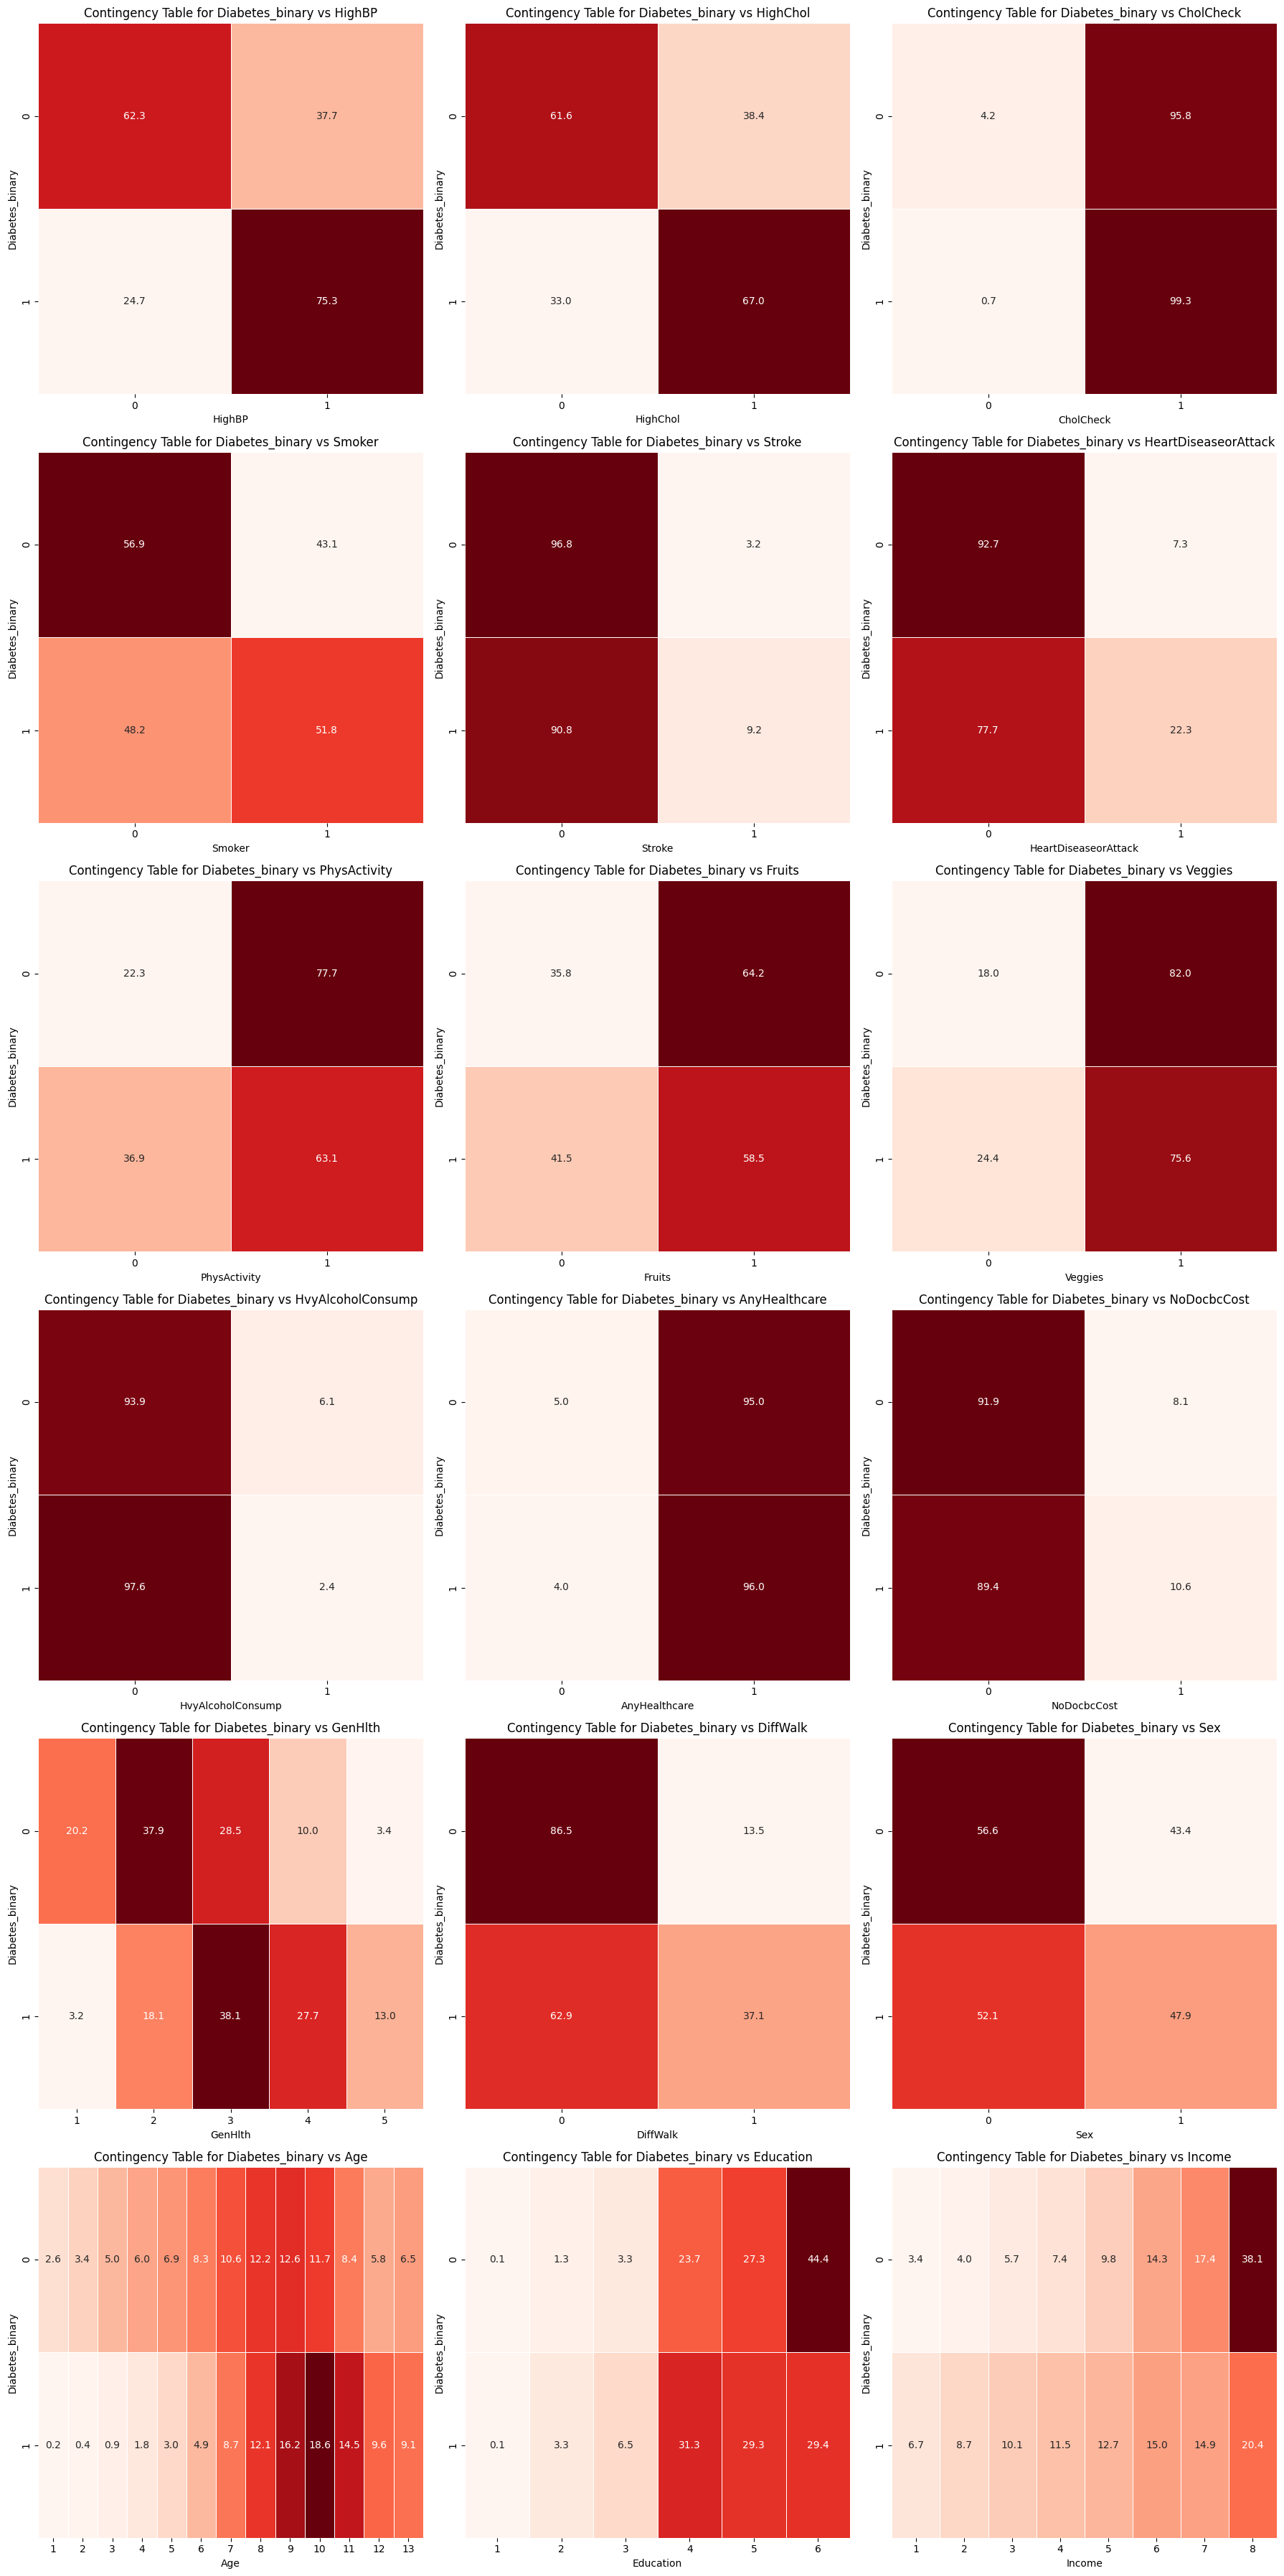

In [ ]:
# Plot the distribution of the target variable against the categorical variables
fig, axes = plt.subplots(6, 3, figsize=(18, 6 * 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    contingency_table = pd.crosstab(df['Diabetes_binary'], df[col], normalize='index') * 100
    sns.heatmap(contingency_table, annot=True, fmt=".1f", cmap='Reds', cbar=False, linewidths=0.5, ax=axes[i])
    axes[i].set_title(f"Contingency Table for Diabetes_binary vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Diabetes_binary')
plt.tight_layout()    
plt.show()

**Notes:**

From the contingency tables above, we notice that those who are diagnosed with prediabetes or diabetes, expectedly tend to have: 

1- High blood pressure

2- High cholestrol


Relationship between diabetes and the other factors included in the dataset is not clear, either for insignificant proportion differences or imbalanced frequency of feature categories.

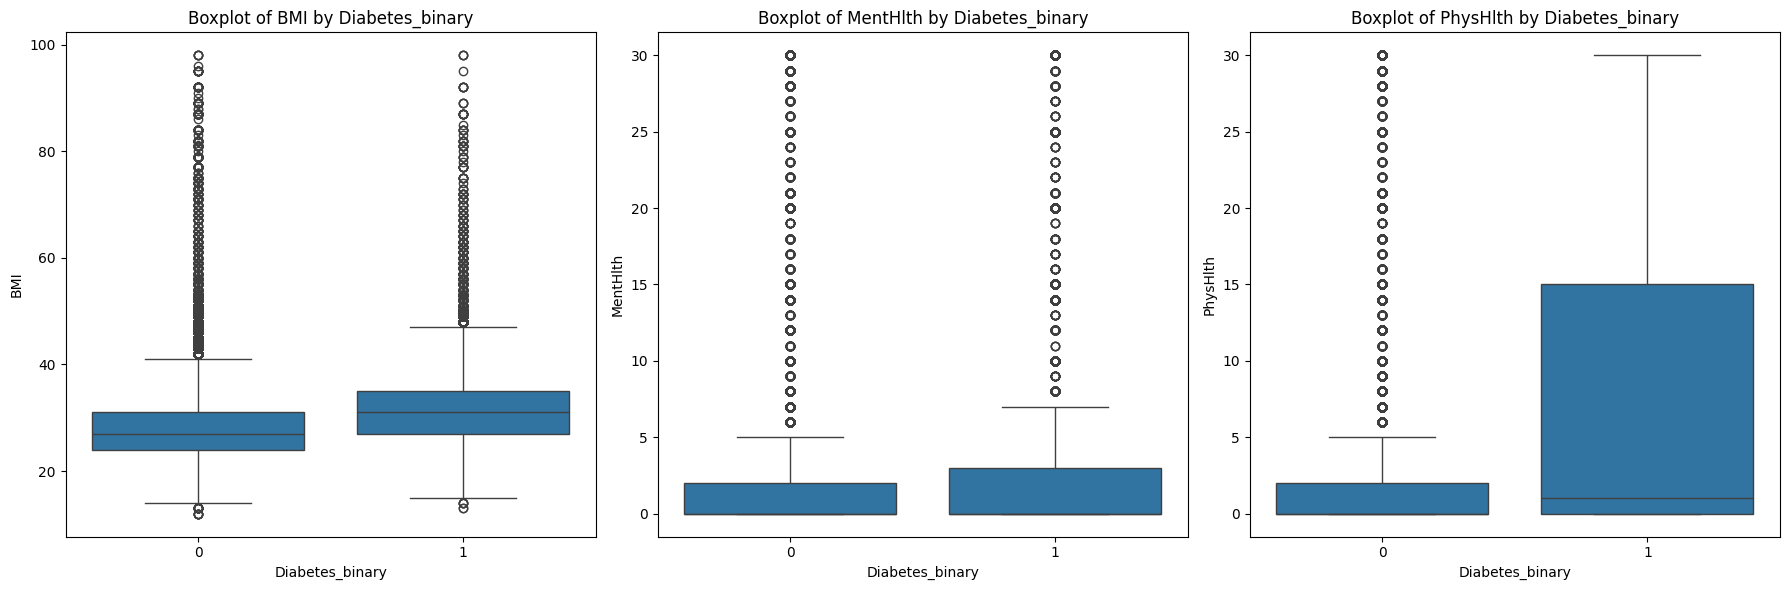

In [10]:
# Plot the distribution of the target variable against the numerical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Diabetes_binary', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} by Diabetes_binary")
    axes[i].set_xlabel('Diabetes_binary')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

**Notes:**

For BMI, bad mental health and bad physical health, the data is scattered across the two states of diabetes diagnosis, but those who are diagnosed tend to have higher: 

1- BMI

2- Higher number of days that they self-reported as not in good mental health

3- Higher number of days that they self-reported as not in good physcial health

In [11]:
# Return the categorical variables to their original types to use in correlation analysis
df = df.astype({col:'int64' for col in cat_cols})
df.dtypes

Diabetes_binary         category
HighBP                     int64
HighChol                   int64
CholCheck                  int64
BMI                        int64
Smoker                     int64
Stroke                     int64
HeartDiseaseorAttack       int64
PhysActivity               int64
Fruits                     int64
Veggies                    int64
HvyAlcoholConsump          int64
AnyHealthcare              int64
NoDocbcCost                int64
GenHlth                    int64
MentHlth                   int64
PhysHlth                   int64
DiffWalk                   int64
Sex                        int64
Age                        int64
Education                  int64
Income                     int64
dtype: object

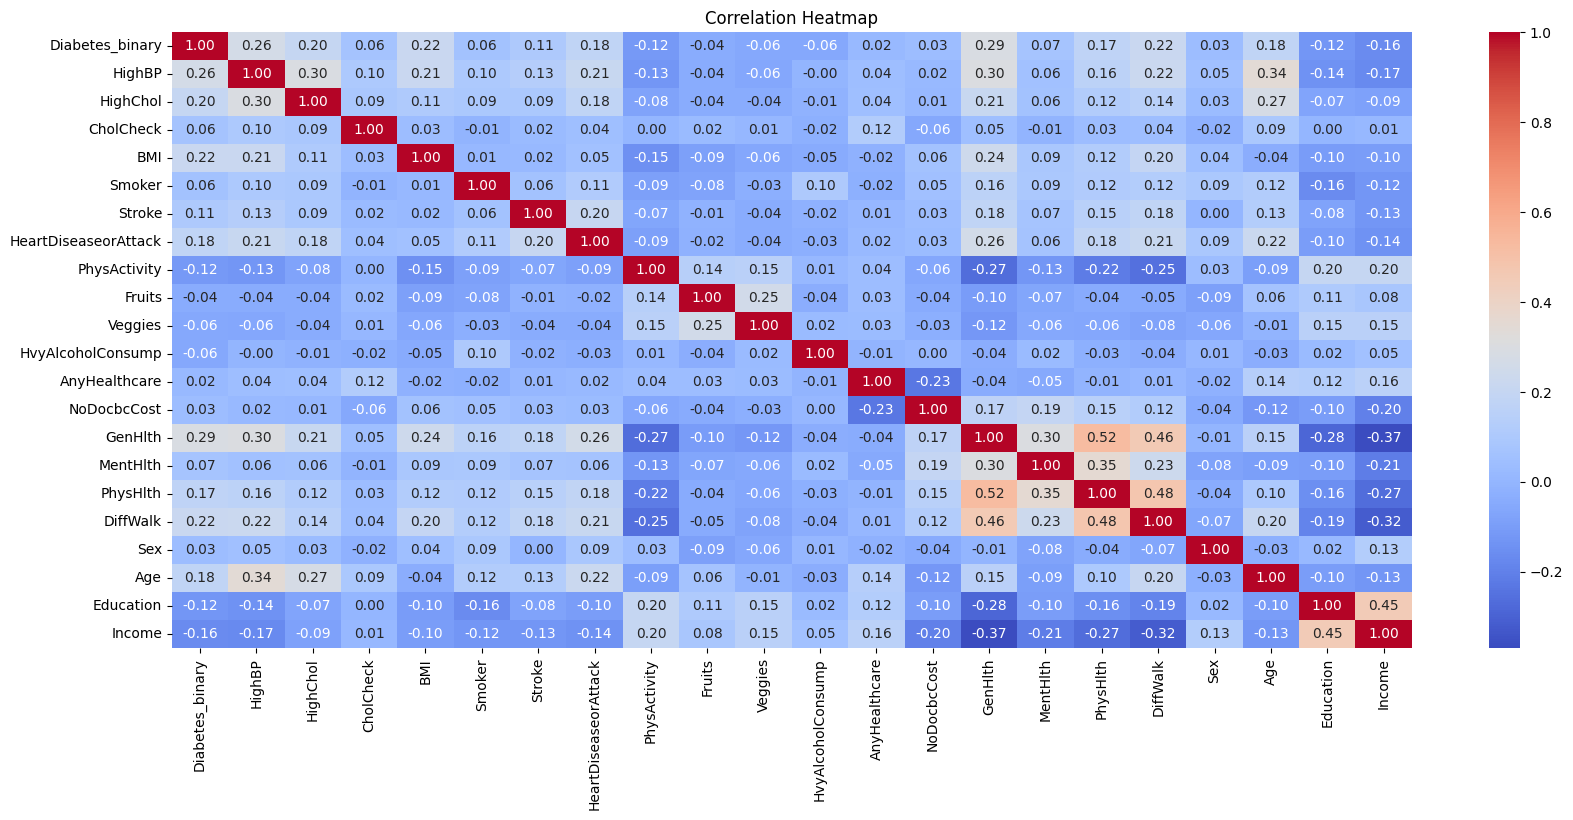

In [ ]:
# Check the correlation between the variables
fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=ax)
plt.title('Correlation Heatmap')
plt.show()

**Note:** The correlation coefficients among the variables are dominantly non-significant (way below absolute 0.4), except between:

- GnHlth (general health) and PhysHlth (physical health) at 0.52
- PhysHlth (physical health) and DiffWalk (difficualty of walking) at 0.48
- GnHlth (general health) and DiffWalk (difficualty of walking) at 0.46

No relevant action is needed.

## Data preparation

### Treating imbalance with SMOTE oversampling

In [15]:
# Creating X and y datasets
# X will contain all the features, and y will contain the target variable
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

# Initial train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

# Applying SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=888, sampling_strategy='auto')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the balance of the target variable before and after SMOTE
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: Diabetes_binary
0    174754
1     28190
Name: count, dtype: int64
After SMOTE: Diabetes_binary
0    174754
1    174754
Name: count, dtype: int64


### Feature selection with Recursive Feature Elimination (RFE)

RFE is a feature selection technique that helps identify the most important features for a machine learning model. It works by iteratively removing the least significant features and retraining the model until only the most relevant features remain. 

Applying it here in this context aims to avoid noisy and redundant features and avoid picking up unnecessary patterns, as well as reducing computational cost.


In [16]:
# Fit a Random Forest Classifier to the resampled data
rf = RandomForestClassifier(random_state=888)
# Apply RFE for feature selection
rfe = RFE(estimator=rf, n_features_to_select=11)
X_selected = rfe.fit_transform(X_train_resampled, y_train_resampled)
# Show the selected features
selected_features = X_train.columns[rfe.support_]
print("Selected Features:", selected_features.tolist())

Selected Features: ['HighBP', 'HighChol', 'BMI', 'PhysActivity', 'GenHlth', 'MentHlth', 'PhysHlth', 'Sex', 'Age', 'Education', 'Income']


## Modeling and evaluation

### Hyperparameter tuning with Bayesian Optimization

Bayesian optimization is a technique to tune hyperparameters more efficiently than grid or random search. Instead of blindly searching, it learns from previous iterations and adjusts accordingly to find the optimal values faster.

Recall is chosen as the basis scoring method to maximize, in order to minimize false negatives and minimize the chances of missing diabetes cases.

In [ ]:
# Defining the RFE function for feature selection with the defined search space
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    max_depth = trial.suggest_int('max_depth', 5, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 6)
    # Create a Random Forest Classifier with the suggested hyperparameters
    rf_tuned = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=888
    )
    # Evaluate each trial with cross-validation based on recall score
    # Recall is chosen to minimize false negatives and minimize the chances of missing diabetes cases
    score = cross_val_score(rf_tuned, X_selected, y_train_resampled, cv=4, scoring='recall') 
    return score.mean()

In [18]:
# Create a study object and optimize the objective function
study = optuna.create_study(study_name='Best params for RF',
                            direction='maximize')
study.optimize(objective, n_trials=15)
# Print the best hyperparameters and score
print("Best hyperparameters:", study.best_params)
print("Best score:", study.best_value)

[I 2025-05-03 19:47:10,002] A new study created in memory with name: Best params for RF
[I 2025-05-03 19:53:48,476] Trial 0 finished with value: 0.7814870633406843 and parameters: {'n_estimators': 299, 'max_depth': 9, 'min_samples_split': 5}. Best is trial 0 with value: 0.7814870633406843.
[I 2025-05-03 20:01:42,529] Trial 1 finished with value: 0.8847463236144872 and parameters: {'n_estimators': 239, 'max_depth': 20, 'min_samples_split': 3}. Best is trial 1 with value: 0.8847463236144872.
[I 2025-05-03 20:04:15,145] Trial 2 finished with value: 0.8103218265820193 and parameters: {'n_estimators': 109, 'max_depth': 13, 'min_samples_split': 6}. Best is trial 1 with value: 0.8847463236144872.
[I 2025-05-03 20:08:06,509] Trial 3 finished with value: 0.7724572609054756 and parameters: {'n_estimators': 216, 'max_depth': 7, 'min_samples_split': 3}. Best is trial 1 with value: 0.8847463236144872.
[I 2025-05-03 20:16:37,742] Trial 4 finished with value: 0.7820822035712385 and parameters: {'n_es

Best hyperparameters: {'n_estimators': 239, 'max_depth': 20, 'min_samples_split': 3}
Best score: 0.8847463236144872


### Training final model with optimized parameters

In [19]:
# Use the best hyperparameters to fit the final model
best_params = study.best_params
rf_final = RandomForestClassifier(**best_params, random_state=888)
rf_final.fit(X_selected, y_train_resampled) # X_selected is the selected features from RFE

RandomForestClassifier(max_depth=20, min_samples_split=3, n_estimators=239,
                       random_state=888)

### Evaluating final model performance

In [20]:
# Evaluate the model on the test set
y_pred = rf_final.predict(X_test[selected_features])
# Calculate the classification report and ROC AUC score
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, rf_final.predict_proba(X_test[selected_features])[:, 1]))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85     43580
           1       0.31      0.58      0.40      7156

    accuracy                           0.76     50736
   macro avg       0.61      0.68      0.63     50736
weighted avg       0.83      0.76      0.78     50736

ROC AUC Score: 0.7724909612847469


**Notes:**

The classification report provides key insights into the model’s precision, recall, and F1-score, helping to evaluate how well it classifies pre-diabetic or diabetic (1) vs. non-diabetic (0) cases.

**Class 0 (Non-Diabetic Patients)**
- Precision: 0.92 → When the model predicts a patient as non-diabetic, it’s correct 92% of the time (low false positives).
- Recall: 0.79 → It correctly identifies 79% of actual non-diabetic patients, but misses 21% (false negatives).
- F1-score: 0.85 → A strong balance between precision and recall for non-diabetic cases.

**Class 1 (Pre-Diabetic and Diabetic Patients)**
- Precision: 0.31 → When the model predicts diabetes, only 31% are actually diabetic, meaning false positives are quite high.
- Recall: 0.58 → The model correctly identifies 58% of actual diabetic cases, but misses 42% (false negatives).
- F1-score: 0.40 → A weaker balance, indicating the model struggles to confidently predict diabetes cases.

**Overall Model Performance**
- Accuracy: 76% → Reasonable, but not the best metric for imbalanced datasets.
- Macro Avg Recall (0.68) → Indicates that, on average, recall across both classes is decent but still has room for improvement, particularly for Class 1.
- Weighted Avg F1-score (0.78) → Reflects overall model balance, mainly influenced by Class 0.

**ROC AUC Score: 0.77**
- The ROC AUC score (0.77) shows how well the model distinguishes between diabetic and non-diabetic patients.
- Higher AUC (closer to 1) = better separation between classes
- 0.77 is decent but suggests the model isn’t fully optimized for diabetic case detection.

**Action to be taken:** Adjusting classification threshold to increase recall.


### Feature importance analysis

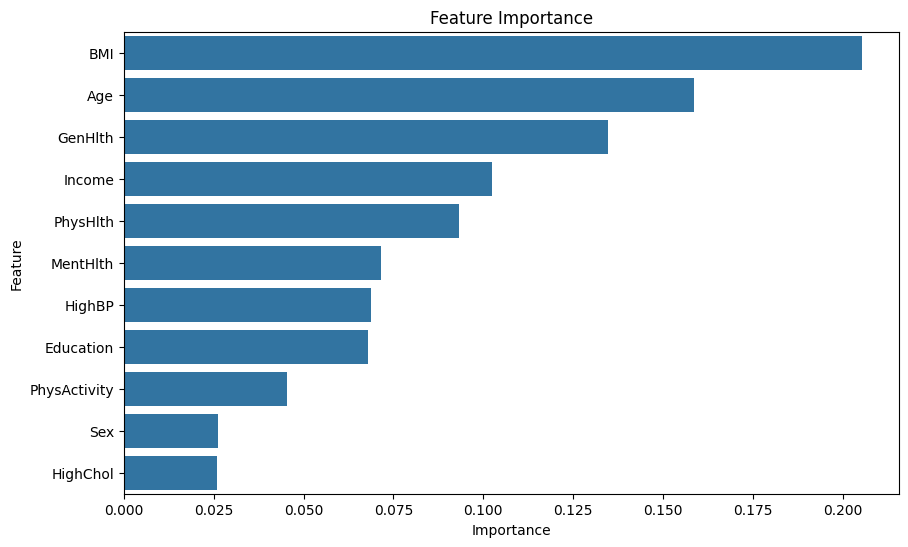

In [21]:
# Extract the feature importances and plot them
importance = rf_final.feature_importances_
features = selected_features.tolist()
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.sort_values(by='Importance', ascending=False))
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()

**Note:** The top five contributing features are:
- BMI
- Age
- General Health
- Income
- Physical Health

### Fine tuning by lowering classification threshold

In [22]:
y_probs = rf_final.predict_proba(X_test[selected_features])[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
best_threshold = thresholds[np.argmax(precision + recall)]

custom_threshold = 0.32
y_pred_custom = (y_probs >= custom_threshold).astype(int)
print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.95      0.62      0.75     43580
           1       0.26      0.79      0.39      7156

    accuracy                           0.65     50736
   macro avg       0.60      0.71      0.57     50736
weighted avg       0.85      0.65      0.70     50736



**Notes:** After adjusting the classification threshold, the classification report shows significant changes in recall for Class 1 (pre-diabetic and diabetic cases).

**Class 0 (Non-Diabetic Patients)**
- Precision: 0.95 → If the model predicts a patient as non-diabetic, it’s correct 95% of the time (very few false positives).
- Recall: 0.62 → However, it only correctly identifies 62% of actual non-diabetic cases, meaning 38% of non-diabetics are misclassified as diabetic (higher false positives).
- F1-score: 0.75 → Shows a reasonable balance between precision and recall for non-diabetics.

**Class 1 (Pre-diabetic and Diabetic Patients)**
- Precision: 0.26 → When the model predicts diabetes, only 26% of those predictions are correct, meaning false positives are high.
- Recall: 0.79 → The model correctly identifies 79% of actual diabetic cases, which is a major improvement compared to performance before the classification threshold adjustment.
- F1-score: 0.39 → Indicates an overall weak balance, but reflects the trade-off: prioritizing recall while sacrificing precision.

**Overall Model Performance**
- Accuracy: 65% → Lower than traditional models, but reasonable for imbalanced medical datasets where recall matters more.
- Macro Avg Recall: 0.71 → Shows improved sensitivity across both classes, favoring capturing diabetic cases (higher recall for Class 1).
- Weighted Avg F1-score: 0.70 → Suggests a trade-off where the model detects more diabetic cases at the cost of misclassifying healthy patients.

**Interpretation & Trade-Off**
- The model now catches more diabetic cases (recall ↑) → Lower false negatives.
- Higher false positives for non-diabetic cases (precision ↓) → More healthy individuals flagged incorrectly.
- Accuracy dropped compared to initial versions → But that’s expected when boosting recall.



## Explaining the model with SHAP (SHapley Additive exPlanations) 

SHAP (SHapley Additive Explanations) is an advanced interpretability technique that explains how individual features contribute to a machine learning model's predictions. In our case, SHAP is crucial for understanding how the Random Forest model determines whether a patient is diabetic or non-diabetic, ensuring transparency in medical decision-making. By assigning SHAP values to features, we can see which factors—such as glucose levels, age, and BMI—impact predictions the most, allowing for improved trust, model debugging, and feature importance analysis. This is particularly valuable for mitigating biases and ensuring that the model’s predictions align with medical reasoning.

In [ ]:
# Initialize SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_final, feature_perturbation='tree_path_dependent')
shap_values = explainer.shap_values(X_test[selected_features][:1000])[1] # Include only first 1000 samples for quicker computation
# Plot the SHAP summary plot for the selected features
shap.summary_plot(shap_values, X_test[selected_features][:1000])
